# Jaccpot GPU Runtime Benchmark (Radix Tree)

This notebook benchmarks Jaccpot runtime on GPU using yggdrax radix-tree settings tuned for throughput.

Included plots:
- `Runtime scaling with particle count (full vs prepared split)`
- `prepare_state component breakdown`

In [1]:
import os

# --- Option A: automatic GPU selection with autocvd ---
USE_AUTOCVD = False
AUTOCVD_NUM_GPUS = 1
AUTOCVD_LEAST_USED = True
AUTOCVD_EXCLUDE = []

# --- Option B: manual selection (set to string like '0' or '0,1') ---
MANUAL_CUDA_VISIBLE_DEVICES = "0,1"  # None #"1,2,3,4,5,6,7,8,9"#None

if MANUAL_CUDA_VISIBLE_DEVICES is not None:
    os.environ["CUDA_VISIBLE_DEVICES"] = MANUAL_CUDA_VISIBLE_DEVICES
    print("Set CUDA_VISIBLE_DEVICES =", os.environ["CUDA_VISIBLE_DEVICES"])
elif USE_AUTOCVD:
    try:
        from autocvd import autocvd

        autocvd(
            num_gpus=AUTOCVD_NUM_GPUS,
            least_used=AUTOCVD_LEAST_USED,
            exclude=AUTOCVD_EXCLUDE,
        )
        print(
            "autocvd selected CUDA_VISIBLE_DEVICES =",
            os.environ.get("CUDA_VISIBLE_DEVICES"),
        )
    except ImportError:
        print(
            "autocvd is not installed. Install it or set MANUAL_CUDA_VISIBLE_DEVICES."
        )
else:
    print(
        "Using existing CUDA visibility:",
        os.environ.get("CUDA_VISIBLE_DEVICES", "<all visible>"),
    )

# GPU memory-fragmentation / graph-memory safeguards.
os.environ.setdefault("TF_GPU_ALLOCATOR", "cuda_malloc_async")
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
if "--xla_gpu_enable_command_buffer=" not in os.environ.get("XLA_FLAGS", ""):
    existing_xla_flags = os.environ.get("XLA_FLAGS", "").strip()
    command_buffer_off = "--xla_gpu_enable_command_buffer="
    os.environ["XLA_FLAGS"] = (
        f"{existing_xla_flags} {command_buffer_off}".strip()
        if existing_xla_flags
        else command_buffer_off
    )

Set CUDA_VISIBLE_DEVICES = 0,1


In [2]:
import json
import pathlib
import subprocess
import sys
import inspect

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = pathlib.Path.cwd().resolve()
if not (REPO_ROOT / "jaccpot").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

from jaccpot import (
    FMMAdvancedConfig,
    FMMPreset,
    FarFieldConfig,
    FastMultipoleMethod,
    NearFieldConfig,
    RuntimePolicyConfig,
    TreeConfig,
)
from yggdrax import Tree, compute_tree_geometry
from yggdrax.interactions import DualTreeTraversalConfig, build_interactions_and_neighbors

from examples import benchmark_utils as bench_utils

In [3]:
# GPU sanity check
all_devices = jax.devices()
gpu_devices = [d for d in all_devices if d.platform == "gpu"]
print("JAX backend:", jax.default_backend())
print("Visible devices:", all_devices)
if not gpu_devices:
    raise RuntimeError(
        "No GPU device visible to JAX. Ensure CUDA/ROCm is configured before running this notebook."
    )
print("Using GPU:", gpu_devices[0])

JAX backend: gpu
Visible devices: [CudaDevice(id=0), CudaDevice(id=1)]
Using GPU: cuda:0


## Benchmark Configuration

In [4]:
# Particle-count sweep for scaling plots (includes your target N=131072)
runtime_particle_counts = [8192, 16384, 32768, 65536, 131072, 262144, 524288, 1048576, 2097152, 4194304, 8388608, 16777216]
runtime_leaf_size = 64
runtime_max_order = 4
runtime_runs = 3
runtime_warmup = 1
runtime_isolate_process_per_n = True
runtime_autotune_cache_path = REPO_ROOT / "benchmarks" / "m2l_autotune_cache.json"

# GPU-oriented precision for large-N profiling
runtime_precision = "fp32"
runtime_working_dtype = jnp.float32
runtime_adaptive_p_gears = (2, 3, 4)
runtime_adaptive_error_model = "dehnen_degree"
runtime_adaptive_eps = 5e-4
runtime_adaptive_mac_force_scale_mode = "prev"
autotune_warmup_counts = [65536, 131072]
accuracy_particle_counts = [4096, 16384, 65536]
runtime_key = jax.random.PRNGKey(0)
softening = 1e-3

# Compare a fiducial large-N preset against adaptive-order + error-controlled MAC.
runtime_fmm_kwargs_fiducial = dict(
    preset=FMMPreset.LARGE_N_GPU,
    basis="solidfmm",
    precision=runtime_precision,
    theta=0.6,
    softening=softening,
    working_dtype=runtime_working_dtype,
    adaptive_order=False,
)
runtime_fmm_kwargs_adaptive = dict(
    **runtime_fmm_kwargs_fiducial,
    adaptive_order=True,
    p_gears=runtime_adaptive_p_gears,
    adaptive_error_model=runtime_adaptive_error_model,
    adaptive_eps=runtime_adaptive_eps,
    mac_force_scale_mode=runtime_adaptive_mac_force_scale_mode,
)
runtime_setups = {
    "fiducial": runtime_fmm_kwargs_fiducial,
    "adaptive_error_mac": runtime_fmm_kwargs_adaptive,
}

## Runtime Collection Helpers

In [5]:
def _evaluate_prepared_kwargs(fmm):
    params = inspect.signature(fmm.evaluate_prepared_state).parameters
    if "jit_traversal" in params:
        return {"jit_traversal": True}
    return {}


def _release_runtime_memory(fmm):
    clear_fn = getattr(fmm, "clear_runtime_caches", None)
    if callable(clear_fn):
        clear_fn(clear_jax_compilation=True)
        return
    if hasattr(fmm, "clear_prepared_state_cache"):
        fmm.clear_prepared_state_cache()
    jax.clear_caches()


def _serialize_fmm_kwargs_for_worker(fmm_kwargs):
    probe_fmm = FastMultipoleMethod(**fmm_kwargs)
    advanced = probe_fmm.advanced
    traversal_cfg = advanced.runtime.traversal_config
    traversal_payload = None
    if traversal_cfg is not None:
        traversal_payload = {
            "process_block": int(traversal_cfg.process_block),
            "max_neighbors_per_leaf": int(traversal_cfg.max_neighbors_per_leaf),
            "max_interactions_per_node": int(traversal_cfg.max_interactions_per_node),
            "max_pair_queue": int(traversal_cfg.max_pair_queue),
        }
    preset_value = fmm_kwargs.get("preset", "fast")
    if hasattr(preset_value, "value"):
        preset_value = preset_value.value
    payload = {
        "preset": str(preset_value),
        "basis": str(fmm_kwargs.get("basis", "solidfmm")),
        "theta": float(fmm_kwargs.get("theta", 0.6)),
        "softening": float(fmm_kwargs.get("softening", 1e-3)),
        "working_dtype": str(jnp.dtype(getattr(probe_fmm._impl, "working_dtype", jnp.float32))),
        "tree_type": str(advanced.tree.tree_type),
        "leaf_target": int(advanced.tree.leaf_target),
        "farfield_rotation": str(advanced.farfield.rotation),
        "farfield_mode": str(advanced.farfield.mode),
        "grouped_interactions": bool(advanced.farfield.grouped_interactions),
        "streamed_far_pairs": advanced.farfield.streamed_far_pairs,
        "mixed_order": bool(advanced.farfield.mixed_order),
        "mixed_order_min_order": advanced.farfield.mixed_order_min_order,
        "nearfield_mode": str(advanced.nearfield.mode),
        "nearfield_edge_chunk_size": int(advanced.nearfield.edge_chunk_size),
        "precompute_scatter_schedules": bool(advanced.nearfield.precompute_scatter_schedules),
        "pair_process_block": (
            None
            if advanced.runtime.pair_process_block is None
            else int(advanced.runtime.pair_process_block)
        ),
        "jit_traversal": bool(advanced.runtime.jit_traversal),
        "traversal_config": traversal_payload,
        "enable_interaction_cache": bool(advanced.runtime.enable_interaction_cache),
        "retain_traversal_result": bool(advanced.runtime.retain_traversal_result),
        "retain_interactions": bool(advanced.runtime.retain_interactions),
        "autotune_m2l_chunk": bool(advanced.runtime.autotune_m2l_chunk),
        "adaptive_order": bool(getattr(probe_fmm._impl, "adaptive_order", False)),
        "p_gears": [int(v) for v in getattr(probe_fmm._impl, "p_gears", tuple())],
        "adaptive_error_model": str(getattr(probe_fmm._impl, "adaptive_error_model", "tail_proxy")),
        "adaptive_eps": (
            None
            if getattr(probe_fmm._impl, "adaptive_eps", None) is None
            else float(getattr(probe_fmm._impl, "adaptive_eps"))
        ),
        "mac_force_scale_mode": str(getattr(probe_fmm._impl, "mac_force_scale_mode", "prev")),
        "mac_type": str(advanced.mac_type),
    }
    _release_runtime_memory(probe_fmm)
    return payload


def _run_worker_case(mode, *, num_particles, leaf_size, max_order, runs, warmup, dtype, fmm_kwargs):
    worker_script = REPO_ROOT / "examples" / "benchmark_gpu_radix_worker.py"
    payload = _serialize_fmm_kwargs_for_worker(fmm_kwargs)
    cmd = [
        sys.executable,
        str(worker_script),
        "--mode",
        str(mode),
        "--num-particles",
        str(int(num_particles)),
        "--leaf-size",
        str(int(leaf_size)),
        "--max-order",
        str(int(max_order)),
        "--runs",
        str(int(runs)),
        "--warmup",
        str(int(warmup)),
        "--dtype",
        str(jnp.dtype(dtype)),
        "--seed",
        "0",
        "--autotune-cache",
        str(runtime_autotune_cache_path),
        "--config-json",
        json.dumps(payload),
    ]
    result = subprocess.run(cmd, check=False, capture_output=True, text=True)
    if result.returncode != 0:
        details = (result.stderr or result.stdout or "").strip()
        raise RuntimeError(f"worker failed (exit={result.returncode}): {details}")
    lines = [line.strip() for line in result.stdout.splitlines() if line.strip()]
    if not lines:
        raise RuntimeError("worker produced no output")
    return json.loads(lines[-1])


def sweep_runtimes(
    particle_counts,
    *,
    leaf_size,
    max_order,
    runs,
    warmup,
    dtype,
    key,
    fmm_kwargs,
    strict=False,
):
    records = []
    use_subprocess = bool(globals().get("runtime_isolate_process_per_n", False))
    fmm = None if use_subprocess else FastMultipoleMethod(**fmm_kwargs)
    current_key = key

    for num_particles in particle_counts:
        try:
            if use_subprocess:
                records.append(
                    _run_worker_case(
                        "sweep",
                        num_particles=num_particles,
                        leaf_size=leaf_size,
                        max_order=max_order,
                        runs=runs,
                        warmup=warmup,
                        dtype=dtype,
                        fmm_kwargs=fmm_kwargs,
                    )
                )
                continue

            positions, masses, current_key = bench_utils.generate_random_distribution(
                num_particles,
                key=current_key,
                dtype=dtype,
            )

            full_timing = bench_utils.time_callable(
                fmm.compute_accelerations,
                positions,
                masses,
                leaf_size=leaf_size,
                max_order=max_order,
                reuse_prepared_state=False,
                warmup=warmup,
                runs=runs,
            )

            prepare_once_timing = bench_utils.time_callable(
                fmm.prepare_state,
                positions,
                masses,
                leaf_size=leaf_size,
                max_order=max_order,
                warmup=warmup,
                runs=runs,
            )
            prepared_state = prepare_once_timing.result

            eval_kwargs = _evaluate_prepared_kwargs(fmm)
            eval_timing = bench_utils.time_callable(
                fmm.evaluate_prepared_state,
                prepared_state,
                warmup=warmup,
                runs=runs,
                **eval_kwargs,
            )

            records.append(
                {
                    "num_particles": num_particles,
                    "mean_seconds": full_timing.mean,
                    "std_seconds": full_timing.std,
                    "prepare_mean_seconds": prepare_once_timing.mean,
                    "prepare_std_seconds": prepare_once_timing.std,
                    "evaluate_mean_seconds": eval_timing.mean,
                    "evaluate_std_seconds": eval_timing.std,
                    "error": "",
                }
            )
        except Exception as exc:
            msg = f"{type(exc).__name__}: {exc}"
            print(f"[sweep_runtimes] N={num_particles} failed: {msg}")
            records.append(
                {
                    "num_particles": num_particles,
                    "mean_seconds": float("nan"),
                    "std_seconds": float("nan"),
                    "prepare_mean_seconds": float("nan"),
                    "prepare_std_seconds": float("nan"),
                    "evaluate_mean_seconds": float("nan"),
                    "evaluate_std_seconds": float("nan"),
                    "error": msg,
                }
            )
            if strict:
                raise
        finally:
            if fmm is not None:
                _release_runtime_memory(fmm)

    return pd.DataFrame(records)


def profile_prepare_components(
    particle_counts,
    *,
    leaf_size,
    max_order,
    dtype,
    key,
    fmm_kwargs,
    runs,
    warmup,
    strict=False,
):
    records = []
    use_subprocess = bool(globals().get("runtime_isolate_process_per_n", False))
    fmm = None if use_subprocess else FastMultipoleMethod(**fmm_kwargs)
    current_key = key

    if not use_subprocess:
        tree_type = str(getattr(fmm._impl, "tree_type", "radix"))
        tree_mode = str(getattr(fmm._impl, "tree_build_mode", "lbvh"))
        ygg_build_mode = "fixed_depth" if tree_mode == "fixed_depth" else "adaptive"
        theta_val = float(getattr(fmm._impl, "theta", fmm_kwargs.get("theta", 0.6)))
        traversal_cfg = fmm.advanced.runtime.traversal_config
        mac_type = str(getattr(fmm, "mac_type", "dehnen"))
        dehnen_radius_scale = float(getattr(fmm._impl, "dehnen_radius_scale", 1.0))

    for num_particles in particle_counts:
        try:
            if use_subprocess:
                records.append(
                    _run_worker_case(
                        "prepare",
                        num_particles=num_particles,
                        leaf_size=leaf_size,
                        max_order=max_order,
                        runs=runs,
                        warmup=warmup,
                        dtype=dtype,
                        fmm_kwargs=fmm_kwargs,
                    )
                )
                continue

            positions, masses, current_key = bench_utils.generate_random_distribution(
                num_particles,
                key=current_key,
                dtype=dtype,
            )

            tree_timing = bench_utils.time_callable(
                Tree.from_particles,
                positions,
                masses,
                tree_type=tree_type,
                build_mode=ygg_build_mode,
                return_reordered=True,
                leaf_size=int(leaf_size),
                warmup=warmup,
                runs=runs,
            )

            tree = Tree.from_particles(
                positions,
                masses,
                tree_type=tree_type,
                build_mode=ygg_build_mode,
                return_reordered=True,
                leaf_size=int(leaf_size),
            )
            geometry = compute_tree_geometry(tree, tree.positions_sorted)

            interactions_timing = bench_utils.time_callable(
                build_interactions_and_neighbors,
                tree,
                geometry,
                theta=theta_val,
                traversal_config=traversal_cfg,
                mac_type=mac_type,
                dehnen_radius_scale=dehnen_radius_scale,
                warmup=warmup,
                runs=runs,
            )

            prepare_timing = bench_utils.time_callable(
                fmm.prepare_state,
                positions,
                masses,
                leaf_size=int(leaf_size),
                max_order=max_order,
                warmup=warmup,
                runs=runs,
            )

            residual = max(
                float(prepare_timing.mean)
                - float(tree_timing.mean)
                - float(interactions_timing.mean),
                0.0,
            )
            records.append(
                {
                    "num_particles": num_particles,
                    "tree_build_mean_seconds": float(tree_timing.mean),
                    "interactions_mean_seconds": float(interactions_timing.mean),
                    "upward_mean_seconds": residual,
                    "downward_mean_seconds": 0.0,
                    "prepare_component_sum_seconds": float(prepare_timing.mean),
                    "error": "",
                }
            )
        except Exception as exc:
            msg = f"{type(exc).__name__}: {exc}"
            print(f"[profile_prepare_components] N={num_particles} failed: {msg}")
            records.append(
                {
                    "num_particles": num_particles,
                    "tree_build_mean_seconds": float("nan"),
                    "upward_mean_seconds": float("nan"),
                    "interactions_mean_seconds": float("nan"),
                    "downward_mean_seconds": float("nan"),
                    "prepare_component_sum_seconds": float("nan"),
                    "error": msg,
                }
            )
            if strict:
                raise
        finally:
            if fmm is not None:
                _release_runtime_memory(fmm)

    return pd.DataFrame(records)

## Runtime Scaling (Full vs Prepared Split)

In [6]:
# 1) Warm up autotuning first so benchmark runs use persisted best chunk sizes.
for setup_name, fmm_kwargs in runtime_setups.items():
    for warm_n in autotune_warmup_counts:
        try:
            _ = _run_worker_case(
                "prepare",
                num_particles=warm_n,
                leaf_size=runtime_leaf_size,
                max_order=runtime_max_order,
                runs=1,
                warmup=0,
                dtype=runtime_working_dtype,
                fmm_kwargs=fmm_kwargs,
            )
        except Exception as exc:
            print(f"[autotune_warmup] setup={setup_name} N={warm_n} failed: {type(exc).__name__}: {exc}")

# 2) Runtime sweep for both setups.
runtime_results = {}
for setup_name, fmm_kwargs in runtime_setups.items():
    setup_df = sweep_runtimes(
        runtime_particle_counts,
        leaf_size=runtime_leaf_size,
        max_order=runtime_max_order,
        runs=runtime_runs,
        warmup=runtime_warmup,
        dtype=runtime_working_dtype,
        key=runtime_key,
        fmm_kwargs=fmm_kwargs,
    )
    setup_df["setup"] = setup_name
    runtime_results[setup_name] = setup_df.sort_values("num_particles")

runtime_compare_df = pd.concat(runtime_results.values(), ignore_index=True)
runtime_compare_df

[sweep_runtimes] N=16777216 failed: RuntimeError: worker failed (exit=-11): E0307 18:45:35.949303 1254579 gpu_hlo_schedule.cc:868] The byte size of input/output arguments (105553116266496) exceeds the base limit (33828215193). This indicates an error in the calculation!
E0307 18:45:35.949847 1254578 gpu_hlo_schedule.cc:868] The byte size of input/output arguments (57200374448144) exceeds the base limit (33828215193). This indicates an error in the calculation!
E0307 18:45:35.949838 1254593 gpu_hlo_schedule.cc:868] The byte size of input/output arguments (105553116266496) exceeds the base limit (33828215193). This indicates an error in the calculation!
W0307 18:45:36.027447 1254606 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 12.02GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


,num_particles,mean_seconds,std_seconds,prepare_mean_seconds,prepare_std_seconds,evaluate_mean_seconds,evaluate_std_seconds,error
0,8192,4.252499,1.259208,3.208035,0.941487,0.013241,0.000134,
1,16384,4.202078,1.009332,5.482393,0.223652,0.035581,0.001604,
2,32768,6.080022,0.624350,4.864275,0.686863,0.083565,0.000254,
3,65536,7.154959,2.123598,5.267593,0.053716,0.194143,0.001492,
4,131072,12.177916,1.818205,10.121128,0.450940,0.459463,0.000055,
5,262144,20.257901,1.075054,18.242922,1.235700,1.000387,0.001587,
6,524288,38.946597,0.326650,37.511275,0.172418,2.239538,0.003561,
7,1048576,NaN,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: Out of me...
8,2097152,NaN,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: Out of me...
9,4194304,NaN,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: Out of me...


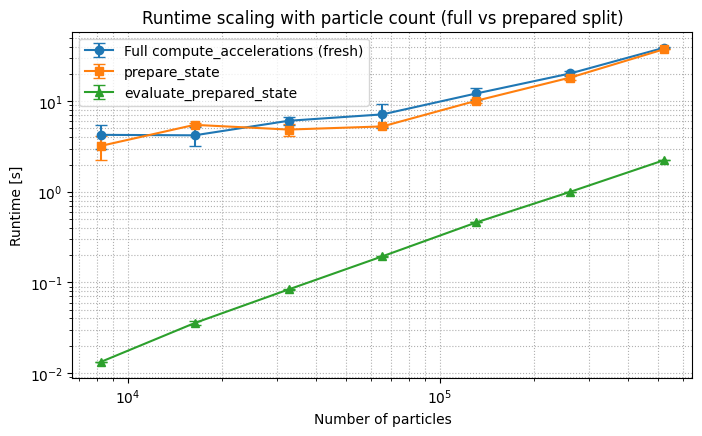

In [7]:
fig, (ax_rt, ax_sp) = plt.subplots(1, 2, figsize=(12, 4.5))

for setup_name, marker in [("fiducial", "o"), ("adaptive_error_mac", "s")]:
    df = runtime_results[setup_name]
    ax_rt.errorbar(
        df["num_particles"],
        df["mean_seconds"],
        yerr=df["std_seconds"],
        fmt=f"{marker}-",
        capsize=4,
        label=f"{setup_name}: full compute",
    )

ax_rt.set_xscale("log")
ax_rt.set_yscale("log")
ax_rt.set_xlabel("Number of particles")
ax_rt.set_ylabel("Runtime [s]")
ax_rt.set_title("Full runtime scaling by setup")
ax_rt.grid(True, which="both", linestyle=":", linewidth=0.8)
ax_rt.legend()

fid = runtime_results["fiducial"][["num_particles", "mean_seconds"]].rename(columns={"mean_seconds": "fiducial_s"})
ada = runtime_results["adaptive_error_mac"][["num_particles", "mean_seconds"]].rename(columns={"mean_seconds": "adaptive_s"})
speed = fid.merge(ada, on="num_particles", how="inner")
speed = speed[(speed["fiducial_s"] > 0) & (speed["adaptive_s"] > 0)].copy()
speed["speedup_x"] = speed["fiducial_s"] / speed["adaptive_s"]

ax_sp.plot(speed["num_particles"], speed["speedup_x"], "d-", color="tab:green")
ax_sp.axhline(1.0, color="gray", linestyle="--", linewidth=1)
ax_sp.set_xscale("log")
ax_sp.set_xlabel("Number of particles")
ax_sp.set_ylabel("Speedup vs fiducial [x]")
ax_sp.set_title("Adaptive+error-MAC speedup")
ax_sp.grid(True, which="both", linestyle=":", linewidth=0.8)

plt.tight_layout()
plt.show()

speed

## Prepare-State Component Breakdown

In [8]:
runtime_component_results = {}
for setup_name, fmm_kwargs in runtime_setups.items():
    comp_df = profile_prepare_components(
        runtime_particle_counts,
        leaf_size=runtime_leaf_size,
        max_order=runtime_max_order,
        dtype=runtime_working_dtype,
        key=runtime_key,
        fmm_kwargs=fmm_kwargs,
        runs=max(1, runtime_runs),
        warmup=runtime_warmup,
    )
    comp_df["setup"] = setup_name
    runtime_component_results[setup_name] = comp_df.sort_values("num_particles")

runtime_component_compare_df = pd.concat(runtime_component_results.values(), ignore_index=True)
runtime_component_compare_df

[profile_prepare_components] N=16777216 failed: RuntimeError: worker failed (exit=-11): E0307 19:06:44.515614 1280215 gpu_hlo_schedule.cc:868] The byte size of input/output arguments (105553116266496) exceeds the base limit (33828215193). This indicates an error in the calculation!
E0307 19:06:44.515685 1280269 gpu_hlo_schedule.cc:868] The byte size of input/output arguments (105553116266496) exceeds the base limit (33828215193). This indicates an error in the calculation!
E0307 19:06:44.516358 1280221 gpu_hlo_schedule.cc:868] The byte size of input/output arguments (57200374448144) exceeds the base limit (33828215193). This indicates an error in the calculation!
W0307 19:06:44.592296 1280266 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 12.02GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
W0307 19:06:44.601216 1280247 bfc_allocator.cc:31

,num_particles,tree_build_mean_seconds,interactions_mean_seconds,upward_mean_seconds,downward_mean_seconds,prepare_component_sum_seconds,error
0,8192,1.599993,0.028042,2.228775,0.0,3.856810,
1,16384,1.656669,0.038740,2.312645,0.0,4.008054,
2,32768,2.139341,0.054972,2.188902,0.0,4.383216,
3,65536,1.449500,0.079697,4.597082,0.0,6.126278,
4,131072,1.427551,0.122729,8.417166,0.0,9.967446,
5,262144,1.430466,0.221232,16.408610,0.0,18.060307,
6,524288,1.307381,0.443667,34.894820,0.0,36.645867,
7,1048576,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: Out of me...
8,2097152,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: Out of me...
9,4194304,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: Out of me...


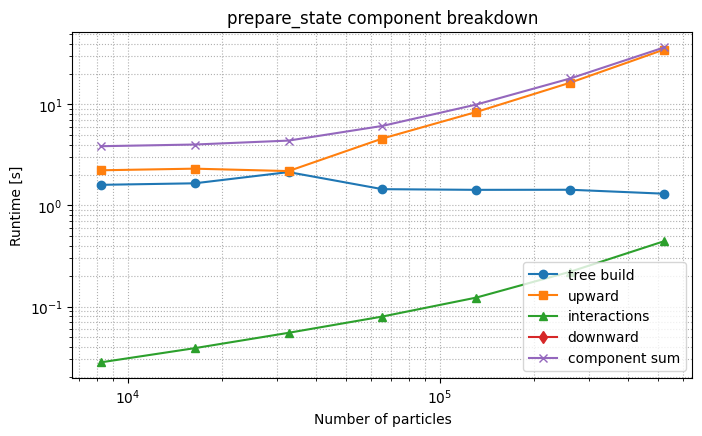

In [9]:
fig, (ax_sum, ax_int) = plt.subplots(1, 2, figsize=(12, 4.5))
for setup_name, marker in [("fiducial", "o"), ("adaptive_error_mac", "s")]:
    cdf = runtime_component_results[setup_name]
    ax_sum.plot(
        cdf["num_particles"],
        cdf["prepare_component_sum_seconds"],
        marker=marker,
        label=f"{setup_name}: prepare total",
    )
    ax_int.plot(
        cdf["num_particles"],
        cdf["interactions_mean_seconds"],
        marker=marker,
        label=f"{setup_name}: interactions",
    )

for ax, title, ylabel in [
    (ax_sum, "prepare_state total", "Runtime [s]"),
    (ax_int, "interaction build", "Runtime [s]"),
]:
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Number of particles")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, which="both", linestyle=":", linewidth=0.8)
    ax.legend()

plt.tight_layout()
plt.show()

## Accuracy Comparison (Vs Fiducial)

Adaptive setup accuracy is measured against fiducial accelerations on the same particle sets.

In [ ]:
accuracy_rows = []
acc_key = runtime_key
for n_particles in accuracy_particle_counts:
    positions, masses, acc_key = bench_utils.generate_random_distribution(
        int(n_particles),
        key=acc_key,
        dtype=runtime_working_dtype,
    )

    fid_fmm = FastMultipoleMethod(**runtime_fmm_kwargs_fiducial)
    ada_fmm = FastMultipoleMethod(**runtime_fmm_kwargs_adaptive)
    if runtime_autotune_cache_path.exists():
        try:
            fid_fmm.load_m2l_autotune_cache(str(runtime_autotune_cache_path), merge=True)
            ada_fmm.load_m2l_autotune_cache(str(runtime_autotune_cache_path), merge=True)
        except Exception as exc:
            print(f"[accuracy] autotune cache load failed for N={n_particles}: {type(exc).__name__}: {exc}")

    fid_acc = fid_fmm.compute_accelerations(
        positions,
        masses,
        leaf_size=runtime_leaf_size,
        max_order=runtime_max_order,
        reuse_prepared_state=False,
    )
    ada_acc = ada_fmm.compute_accelerations(
        positions,
        masses,
        leaf_size=runtime_leaf_size,
        max_order=runtime_max_order,
        reuse_prepared_state=False,
    )

    fid_arr = np.asarray(fid_acc)
    ada_arr = np.asarray(ada_acc)
    diff = ada_arr - fid_arr
    rel_l2 = float(np.linalg.norm(diff) / max(np.linalg.norm(fid_arr), 1e-12))
    denom = np.linalg.norm(fid_arr, axis=1)
    err = np.linalg.norm(diff, axis=1)
    rel_max = float(np.max(err / np.maximum(denom, 1e-12)))

    accuracy_rows.append(
        {
            "num_particles": int(n_particles),
            "relative_l2": rel_l2,
            "relative_max": rel_max,
        }
    )

    fid_fmm.clear_runtime_caches(clear_jax_compilation=True)
    ada_fmm.clear_runtime_caches(clear_jax_compilation=True)

accuracy_df = pd.DataFrame(accuracy_rows).sort_values("num_particles")
accuracy_df

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(accuracy_df["num_particles"], accuracy_df["relative_l2"], "o-", label="relative L2")
ax.plot(accuracy_df["num_particles"], accuracy_df["relative_max"], "s-", label="relative max")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Number of particles")
ax.set_ylabel("Relative error (adaptive vs fiducial)")
ax.set_title("Accuracy impact of adaptive error-controlled MAC")
ax.grid(True, which="both", linestyle=":", linewidth=0.8)
ax.legend()
plt.show()

## Notes

- This notebook is GPU-focused and will fail early if no GPU is visible to JAX.
- `runtime_autotune_cache_path` is used to persist M2L chunk tuning across worker processes and future runs.
- Runtime benchmarking now compares two setups:
  - `fiducial` (`large_n_gpu` preset)
  - `adaptive_error_mac` (adaptive expansion order + error-controlled MAC)
- Run the notebook from the first cell so GPU/XLA environment flags are applied before JAX initializes.